<a href="https://colab.research.google.com/github/hwasun-zip/Saving-Temperature/blob/main/Saving_Temperature.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#환경 설정 (라이브러리 + 한글 폰트)

In [2]:
# 목적: 그래프에 한글이 안 깨지게 하고, 필요한 도구를 불러온다
# ============================================================

# (1) 코랩에 한글 폰트(나눔고딕) 설치 — 코랩 기본 상태면 한글이 □□로 깨짐
!apt-get -qq -y install fonts-nanum > /dev/null

# (2) 기본 라이브러리
import numpy as np              # 숫자 계산
import pandas as pd            # 표(데이터프레임) 다루기
import matplotlib.pyplot as plt # 그래프
import matplotlib.font_manager as fm

# (3) 설치한 나눔고딕을 matplotlib에 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False   # 마이너스 부호(-)도 안 깨지게
plt.rcParams['figure.dpi'] = 120             # 그래프 선명하게 (스크린샷용)

# (4) 재현성 — 매번 같은 결과가 나오게 난수 씨앗 고정
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("환경 설정 완료 ✅  한글 폰트 준비됨, 난수 고정됨(seed=42)")

환경 설정 완료 ✅  한글 폰트 준비됨, 난수 고정됨(seed=42)


In [3]:
#합성 데이터 생성 (26주적금 가입자 패널)

In [4]:
# 합성 데이터 생성 — '적금의 온도' 가입자 패널
# 목적: 실제 고객 데이터 없이도 방법론을 증명할 수 있는
#       26주적금 가입자 1만 명의 행동 데이터를 시뮬레이션한다.
#   ※ 실데이터가 아닌 '시뮬레이션'임을 명확히 함 (개인정보 이슈 회피)
# =====================================================================
rng = np.random.default_rng(RANDOM_SEED)   # Cell 1의 seed=42 → 재현 가능
N = 10000                                    # 26주적금 가입자 수 (가입자 1만명)

# 1) 유저 기본 속성
week = rng.integers(1, 27, N)                # 가입 후 경과 주차(1~26주)
# ★실제 카뱅 26주적금 가입금액 옵션 중 랜덤 선택 (작은 금액일수록 인기 많다고 가정)
base = rng.choice([1000, 2000, 3000, 5000, 10000], N, p=[0.40, 0.25, 0.20, 0.10, 0.05])
weekly_amount = base * week          # 시작 금액 × 주차 = 이번 주 납입액
monthly_income = rng.normal(280, 90, N).clip(80, 900)   # 월소득(만원)
burden = (weekly_amount * 4.3 / 10000) / monthly_income  # 소득 대비 이 적금 부담
burden_norm = (burden - burden.min()) / (burden.max() - burden.min())  # 0~1 정규화

# 2) 은행이 관측 가능한 행동 신호들
balance_buffer    = rng.gamma(2.0, 40, N).clip(1, 500)  # 계좌 여유 잔액(만원)
large_expense     = rng.binomial(1, 0.18, N)            # 최근 대형 지출 발생 여부
income_regular    = rng.beta(5, 2, N)                   # 급여 규칙성(1=안정)
login_drop        = rng.beta(2, 4, N)                   # 앱 접속 빈도 감소폭(1=관심 식음)
payment_delay     = rng.beta(1.5, 6, N)                 # 납입 지연 추세
savings_page_view = rng.poisson(0.7, N)                 # 적금/해지 화면 조회수(탐색 신호)
auto_transfer     = rng.binomial(1, 0.62, N)            # 자동이체 설정 여부
competitor_gap    = rng.normal(0.3, 0.6, N).clip(-1, 2) # 타행 금리 매력(이동 유인)

# 3) 해지를 '원인'별로 분해(해지 점수 만들기)
#   해지는 하나가 아니다 — 사용자 시선으로 3가지 원인으로 나눈다
z_liquidity  = 1.6*large_expense + 1.3*(balance_buffer<30) + 1.1*(1-income_regular)
z_motivation = 3.2*burden_norm + 1.2*(week/26) + 1.3*login_drop + 1.0*payment_delay - 0.8*auto_transfer
z_switch     = 1.4*competitor_gap + 0.45*savings_page_view
cause_scores = np.vstack([z_liquidity, z_motivation, z_switch]).T
cause_names  = np.array(['유동성압박','동기상실','상품이동'])
#도메인 지식으로 신호별 영향력 순서를 정해 계수를 부여하고, 시뮬레이션 결과가 현실적인 해지율·패턴이 되도록 보정. 실제 데이터가 있다면 이 계수는 모델이 학습으로 찾아낼 값

# 4) 관측 해지 라벨 — 여러 원인이 '쌓일수록' 해지 (합산) + 전역절편 -4.0 + 잡음
base_logit = cause_scores.sum(axis=1) - 4.0 + rng.normal(0, 0.4, N)
p_churn_control = 1/(1+np.exp(-base_logit))
churn = rng.binomial(1, p_churn_control)
primary_cause = np.where(churn==1, cause_names[cause_scores.argmax(axis=1)], '해지안함')

# 5) 설득 가능성(uplift) 세그먼트
#   "누가 해지하냐"가 아니라 "개입하면 마음이 바뀌냐"가 진짜 타겟
risk_rank = pd.Series(p_churn_control).rank(pct=True).values
seg = np.empty(N, dtype=object); u = rng.random(N)
at_risk = risk_rank >= 0.60
seg[at_risk]  = np.where(u[at_risk]  < 0.55, '설득가능', '결심형')   # 위험군: 설득가능 vs 결심형
seg[~at_risk] = np.where(u[~at_risk] < 0.15, '잠자는개', '확실유지') # 안전군: 잠자는개 vs 확실유지
# 개입했을 때의 해지 확률(반사실적 결과) — 나중에 uplift 계산에 사용
effect = {'설득가능':-0.35, '결심형':-0.02, '잠자는개':+0.15, '확실유지':0.0}
p_churn_treat = np.clip(p_churn_control + np.array([effect[s] for s in seg]), 0.01, 0.99)
#설득가능 -0.35 → 개입하면 해지 확률이 35%p 뚝 떨어짐 (개입이 먹힘)
#결심형 -0.02 → 개입해도 거의 안 변함 (헛수고)
#잠자는개 +0.15 → 개입하면 해지 확률이 오히려 15%p 올라감 (역효과)
#확실유지 0.0 → 변화 없음

# 6) 데이터프레임 완성
df = pd.DataFrame({
 'user_id':np.arange(N),'week':week,'weekly_amount':weekly_amount,'burden':burden.round(3),
 'balance_buffer':balance_buffer.round(1),'large_expense':large_expense,
 'income_regular':income_regular.round(3),'login_drop':login_drop.round(3),
 'payment_delay':payment_delay.round(3),'savings_page_view':savings_page_view,
 'auto_transfer':auto_transfer,'competitor_gap':competitor_gap.round(3),
 'p_churn_control':p_churn_control.round(3),'p_churn_treat':p_churn_treat.round(3),
 'uplift_segment':seg,'primary_cause':primary_cause,'churn':churn})

print("데이터 생성 완료 ✅  shape:", df.shape)
print("전체 해지율: {:.1%}".format(df.churn.mean()))
df.head()

데이터 생성 완료 ✅  shape: (10000, 17)
전체 해지율: 24.9%


,user_id,week,weekly_amount,burden,balance_buffer,large_expense,income_regular,login_drop,payment_delay,savings_page_view,auto_transfer,competitor_gap,p_churn_control,p_churn_treat,uplift_segment,primary_cause,churn
0,0,3,3000,0.003,40.2,0,0.769,0.052,0.166,1,1,-0.104,0.017,0.017,확실유지,해지안함,0
1,1,21,63000,0.062,57.3,0,0.760,0.397,0.224,1,0,0.583,0.262,0.242,결심형,해지안함,0
2,2,18,54000,0.075,6.5,0,0.552,0.353,0.452,0,1,0.853,0.487,0.467,결심형,유동성압박,1
3,3,12,12000,0.030,97.8,0,0.577,0.616,0.307,0,1,0.347,0.192,0.342,잠자는개,해지안함,0
4,4,12,12000,0.012,38.4,0,0.875,0.225,0.236,0,1,0.453,0.049,0.049,확실유지,해지안함,0


In [5]:
#데이터 탐색/문제 정의 (해지 vs 유지 비교 → Problem 장표)

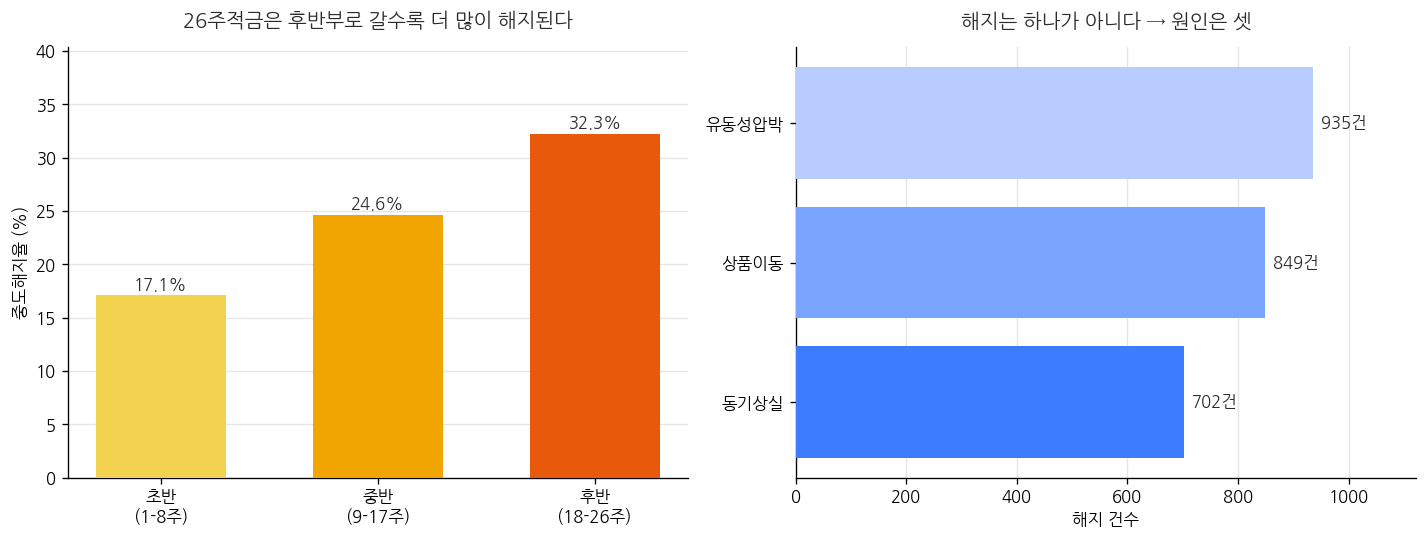

In [6]:
#   ① 후반부로 갈수록 해지 급증 (26주 증액 부담)
#   ② 해지 원인은 하나가 아니다 (원인 3분해의 근거)
# ============================================================
INK='#2b2b2b'; GRID='#e6e6e6'
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))

# ① 주차대별 해지율 (온도색: 노랑→주황→빨강)
bins = pd.cut(df.week, [0,8,17,26], labels=['초반\n(1-8주)','중반\n(9-17주)','후반\n(18-26주)']) # 주차를 초반/중반/후반으로 묶기
rate = df.groupby(bins, observed=True).churn.mean() * 100 # 구간별 해지율(%) 계산
ax = axes[0] # 왼쪽 칸 선택
ax.bar(range(3), rate.values, color=['#F3D250','#F0A500','#E8590C'], width=0.6, zorder=3)
ax.set_xticks(range(3)); ax.set_xticklabels(rate.index)
for i, v in enumerate(rate.values):
    ax.text(i, v+0.5, f'{v:.1f}%', ha='center', fontweight='bold', color=INK)
ax.set_title('26주적금은 후반부로 갈수록 더 많이 해지된다', fontweight='bold', color=INK, pad=12)
ax.set_ylabel('중도해지율 (%)'); ax.set_ylim(0, rate.max()*1.25)
ax.grid(axis='y', color=GRID, zorder=0); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)

# ② 해지 원인별 분포
cc = df[df.churn==1].primary_cause.value_counts() # 해지한 사람만 걸러내기(필터)+원인별로 개수 세기
ax = axes[1]
ax.barh(cc.index[::-1], cc.values[::-1], color=['#3D7BFF','#7AA5FF','#B9CCFF'], zorder=3)
for i, v in enumerate(cc.values[::-1]):
    ax.text(v+15, i, f'{v:,}건', va='center', color=INK, fontweight='bold')
ax.set_title('해지는 하나가 아니다 → 원인은 셋', fontweight='bold', color=INK, pad=12)
ax.set_xlabel('해지 건수'); ax.set_xlim(0, cc.max()*1.2)
ax.grid(axis='x', color=GRID, zorder=0); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig('problem_chart.png', dpi=130, bbox_inches='tight')  # 포트폴리오용 저장
plt.show()

In [7]:
#해지 예측 모델 + 피처 중요도 (Data Modeling 장표)

In [8]:
# 해지 예측 모델 학습 & 평가
#   관측 가능한 행동 신호만으로 '누가 해지할까'를 예측한다
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix

# ① 입력(X)과 정답(y) — 관측 가능한 신호만 (누수 방지)
FEATURES = ['week','weekly_amount','burden','balance_buffer','large_expense',
            'income_regular','login_drop','payment_delay','savings_page_view',
            'auto_transfer','competitor_gap']
X, y = df[FEATURES], df['churn']
# 실제 운영 시 확보 가능한 행동 신호만 사용하고, 시뮬레이션으로 만든 잠재변수는 데이터 누수 방지를 위해 제외

# ② 학습용 75% / 시험용 25% 로 분리 (해지 비율 유지, 재현 고정)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# ③ 성능용 모델: 랜덤포레스트
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=20, random_state=42)
rf.fit(X_tr, y_tr)
rf_prob = rf.predict_proba(X_te)[:, 1] # 해지 확률만 고름

# ④ 해석용 모델: 로지스틱 회귀 (표준화 후)
scaler = StandardScaler()
lr = LogisticRegression(max_iter=1000)
lr.fit(scaler.fit_transform(X_tr), y_tr) # 로지스틱은 스케일에 민감해서 표준화 먼저
lr_prob = lr.predict_proba(scaler.transform(X_te))[:, 1] # 해지 확률만 고름

# ⑤ 성능 비교
print("[모델 성능 - AUC]")
print(f"  랜덤포레스트 : {roc_auc_score(y_te, rf_prob):.3f}")
print(f"  로지스틱회귀 : {roc_auc_score(y_te, lr_prob):.3f}")
print("\n[혼동행렬 - 랜덤포레스트 @기본 0.5]")
print(confusion_matrix(y_te, (rf_prob >= 0.5).astype(int)))

# ⑥ 전체 고객의 해지 위험점수 예측 → df에 저장
df['churn_score'] = rf.predict_proba(df[FEATURES])[:, 1]
print("\n예측 완료 ✅  churn_score 컬럼 추가됨")

[모델 성능 - AUC]
  랜덤포레스트 : 0.779
  로지스틱회귀 : 0.773

[혼동행렬 - 랜덤포레스트 @기본 0.5]
[[1820   59]
 [ 481  140]]

예측 완료 ✅  churn_score 컬럼 추가됨


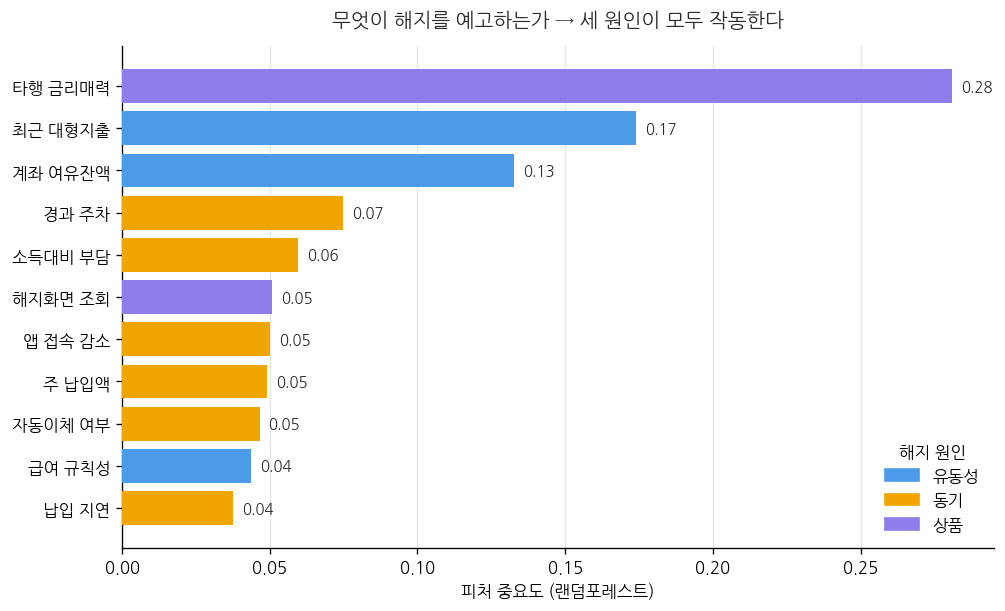

In [9]:
# 피처 중요도 — '무엇이 해지를 예고하는가'
#   포트폴리오 'Data Modeling' 장표: 세 원인이 모두 작동함을 시각화
# ==================================================================
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values() # 각 신호가 예측에 기여한 정도(0~1) 계산

# 각 신호를 3가지 해지 원인으로 색 구분 (11개 신호를 유동성/동기/상품 3그룹 색으로 구분)
group = {'large_expense':'유동성','balance_buffer':'유동성','income_regular':'유동성',
         'burden':'동기','weekly_amount':'동기','week':'동기','login_drop':'동기',
         'payment_delay':'동기','auto_transfer':'동기',
         'competitor_gap':'상품','savings_page_view':'상품'}
col   = {'유동성':'#4C9BE8','동기':'#F0A500','상품':'#8E7CE8'}
label = {'week':'경과 주차','weekly_amount':'주 납입액','burden':'소득대비 부담',
         'balance_buffer':'계좌 여유잔액','large_expense':'최근 대형지출','income_regular':'급여 규칙성',
         'login_drop':'앱 접속 감소','payment_delay':'납입 지연','savings_page_view':'해지화면 조회',
         'auto_transfer':'자동이체 여부','competitor_gap':'타행 금리매력'}
colors = [col[group[f]] for f in imp.index]
names  = [label[f] for f in imp.index]

fig, ax = plt.subplots(figsize=(8.5, 5.2))
ax.barh(names, imp.values, color=colors, zorder=3)
for i, v in enumerate(imp.values):
    ax.text(v+0.003, i, f'{v:.2f}', va='center', color='#2b2b2b', fontsize=9)
ax.set_title('무엇이 해지를 예고하는가 → 세 원인이 모두 작동한다', fontweight='bold', color='#2b2b2b', pad=12)
ax.set_xlabel('피처 중요도 (랜덤포레스트)')
ax.grid(axis='x', color='#e6e6e6', zorder=0); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)

from matplotlib.patches import Patch
legend = [Patch(color=col[g], label=g) for g in ['유동성','동기','상품']]
ax.legend(handles=legend, title='해지 원인', loc='lower right', frameon=False)
plt.tight_layout()
plt.savefig('importance_chart.png', dpi=130, bbox_inches='tight')
plt.show()

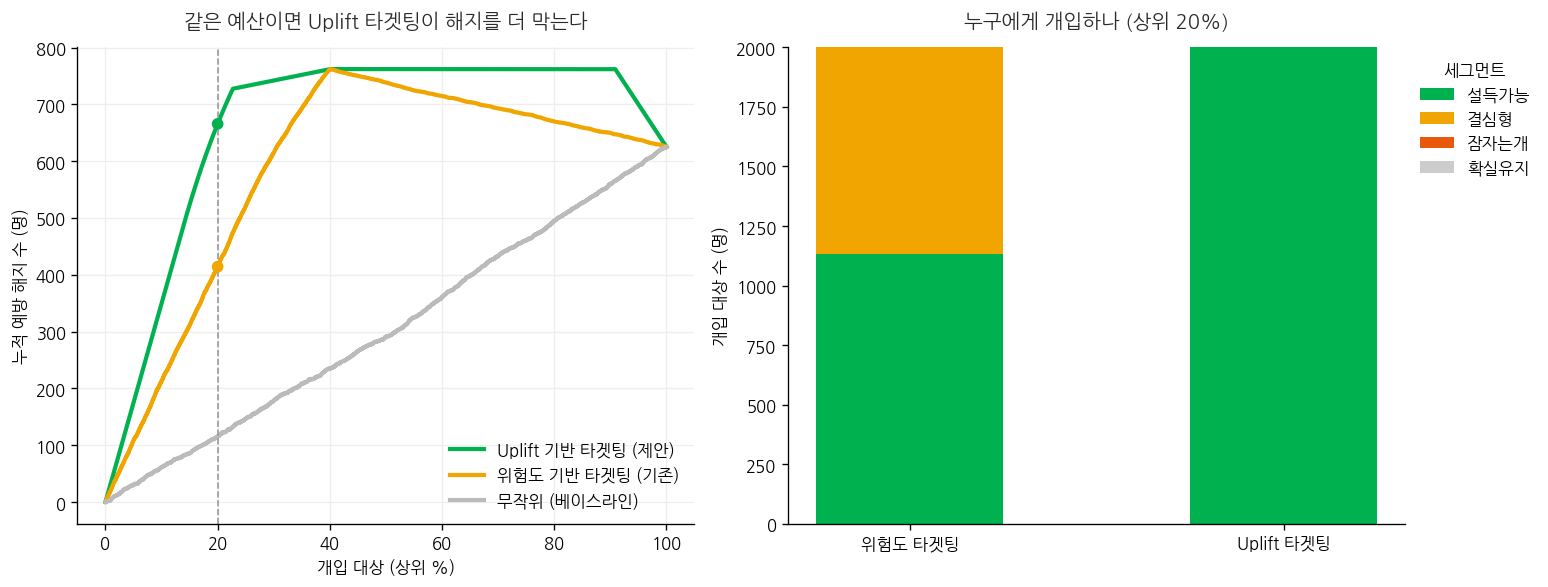

상위 20% 개입 시 예방 해지 → Uplift: 666명 / 위험도: 414명 (차이 251명)


In [10]:
# 개입 대상 최적화
#   "위험한 사람"이 아니라 "설득 가능한 사람"에게 개입하라
# ============================================================
# 실제 개입 효과(uplift) = 개입 안 함 - 개입 함  (양수=예방, 음수=역효과)
df['true_uplift'] = df.p_churn_control - df.p_churn_treat
N = len(df)

# 세 가지 개입 전략의 정렬 순서
risk_order   = np.argsort(-df.p_churn_control.values)  # 위험도 높은 순
uplift_order = np.argsort(-df.true_uplift.values)       # 설득가능 높은 순
rng = np.random.default_rng(0); rand_order = rng.permutation(N)  # 무작위(비교용)

kx = int(N*0.20)   # 예산: 상위 20% = 2000명에게만 개입
py_up = np.cumsum(df.true_uplift.values[uplift_order])[kx-1]
py_rk = np.cumsum(df.true_uplift.values[risk_order])[kx-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 차트1: 누적 예방 해지 곡선
ax = axes[0]
for order, lab, c in [(uplift_order,'Uplift 기반 타겟팅 (제안)','#00B14F'),
                      (risk_order,'위험도 기반 타겟팅 (기존)','#F0A500'),
                      (rand_order,'무작위 (베이스라인)','#BBBBBB')]:
    y = np.cumsum(df.true_uplift.values[order])
    ax.plot(np.arange(1,N+1)/N*100, y, label=lab, color=c, lw=2.5)
ax.axvline(20, ls='--', color='#999', lw=1)
ax.scatter([20,20],[py_up,py_rk], color=['#00B14F','#F0A500'], zorder=5)
ax.set_title('같은 예산이면 Uplift 타겟팅이 해지를 더 막는다', fontweight='bold', color='#2b2b2b', pad=12)
ax.set_xlabel('개입 대상 (상위 %)'); ax.set_ylabel('누적 예방 해지 수 (명)')
ax.legend(frameon=False, loc='lower right'); ax.grid(color='#eee'); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)

# 차트2: 상위 20% 개입 대상의 세그먼트 구성
ax = axes[1]
segs = ['설득가능','결심형','잠자는개','확실유지']
segcol = {'설득가능':'#00B14F','결심형':'#F0A500','잠자는개':'#E8590C','확실유지':'#CCCCCC'}
def comp(order):
    top = df.iloc[order[:kx]]
    return [(top.uplift_segment==s).sum() for s in segs]
rk, up = comp(risk_order), comp(uplift_order)
for i, s in enumerate(segs):
    ax.bar(0, rk[i], bottom=sum(rk[:i]), color=segcol[s], width=0.5)
    ax.bar(1, up[i], bottom=sum(up[:i]), color=segcol[s], width=0.5, label=s)
ax.set_xticks([0,1]); ax.set_xticklabels(['위험도 타겟팅','Uplift 타겟팅'])
ax.set_title('누구에게 개입하나 (상위 20%)', fontweight='bold', color='#2b2b2b', pad=12)
ax.set_ylabel('개입 대상 수 (명)'); ax.legend(frameon=False, title='세그먼트', bbox_to_anchor=(1,1))
for s in ['top','right']: ax.spines[s].set_visible(False)

plt.tight_layout(); plt.savefig('uplift_chart.png', dpi=130, bbox_inches='tight'); plt.show()
print(f"상위 20% 개입 시 예방 해지 → Uplift: {py_up:.0f}명 / 위험도: {py_rk:.0f}명 (차이 {py_up-py_rk:.0f}명)")

개입 대상: 2000 명
추정원인
유동성압박    940
상품이동     633
동기상실     427
Name: count, dtype: int64

[High] 18주차·위험0.50·유동성압박
 → 부분출금, 긴급출금 안내
 💬 적금을 깨지 마세요. 필요한 만큼만 꺼내고 저축은 이어가요.

[Mid] 23주차·위험0.38·동기상실
 → 납입액 하향 + 1주 쉬어가기 (토닥 메시지)
 💬 이번 주는 쉬어가도 괜찮아요 😊 벌써 23주나 달려오셨는걸요!

[High] 26주차·위험0.56·동기상실
 → 납입액 하향 + 1주 쉬어가기 (토닥 메시지)
 💬 이번 주는 쉬어가도 괜찮아요 😊 벌써 26주나 달려오셨는걸요!


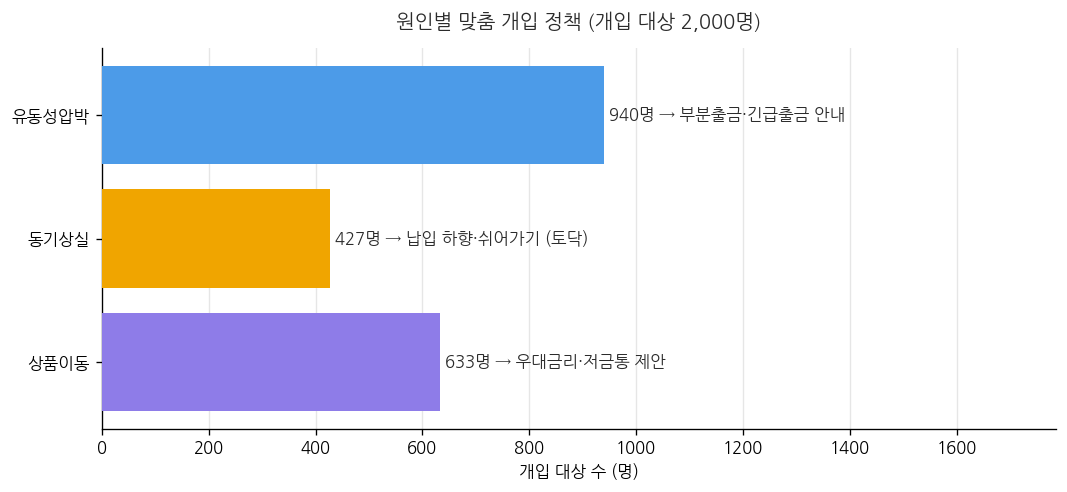

In [11]:
# 정책 엔진 — 원인별 맞춤 개입 (Trigger & Action)
#   "누구에게" 다음은 "무엇을" — 원인별로 다른 처방
# ============================================================
TH = df.churn_score.quantile(0.80)   # 트리거: 위험도 상위 20%만 개입

# 개입 대상의 '주된 원인'을 관측 신호로 추정 (실무에선 별도 모델로 예측)
def infer_cause(r):
    s = {'유동성압박': r.large_expense*1.6 + (r.balance_buffer<30)*1.3 + (1-r.income_regular)*1.1,
         '동기상실':   r.burden*3.2 + (r.week/26)*1.2 + r.login_drop*1.3 + r.payment_delay*1.0 - r.auto_transfer*0.8,
         '상품이동':   r.competitor_gap*1.4 + r.savings_page_view*0.45}
    return max(s, key=s.get)

# 원인별 액션 + 메시지
ACTIONS = {
 '유동성압박':('부분출금, 긴급출금 안내','적금을 깨지 마세요. 필요한 만큼만 꺼내고 저축은 이어가요.'),
 '동기상실':  ('납입액 하향 + 1주 쉬어가기 (토닥 메시지)','이번 주는 쉬어가도 괜찮아요 😊 벌써 {week}주나 달려오셨는걸요!'),
 '상품이동':  ('우대금리, 저금통 연계 제안','더 나은 조건, 카뱅 안에서 찾아드릴게요.')}

def policy(r):
    if r.churn_score < TH:                       # 위험도 낮으면 개입 안 함
        return pd.Series(['개입 안 함','-','-','-'])
    cause = infer_cause(r)
    level = 'High' if r.churn_score >= df.churn_score.quantile(0.90) else 'Mid'  # 강도
    act, msg = ACTIONS[cause]
    return pd.Series([level, cause, act, msg.format(week=r.week)])

df[['개입등급','추정원인','개입액션','메시지']] = df.apply(policy, axis=1)
tgt = df[df.개입등급 != '개입 안 함']
print("개입 대상:", len(tgt), "명")
print(tgt.추정원인.value_counts())
for _, r in tgt.head(3).iterrows():
    print(f"\n[{r.개입등급}] {r.week}주차·위험{r.churn_score:.2f}·{r.추정원인}\n → {r.개입액션}\n 💬 {r.메시지}")

# Policy 장표 차트
cc = tgt.추정원인.value_counts()
actshort = {'유동성압박':'부분출금·긴급출금 안내','동기상실':'납입 하향·쉬어가기 (토닥)','상품이동':'우대금리·저금통 제안'}
col = {'유동성압박':'#4C9BE8','동기상실':'#F0A500','상품이동':'#8E7CE8'}
order = ['유동성압박','동기상실','상품이동']; vals = [cc[o] for o in order]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.barh(range(3), vals, color=[col[o] for o in order], zorder=3)
ax.set_yticks(range(3)); ax.set_yticklabels(order)
for i, o in enumerate(order):
    ax.text(vals[i]+10, i, f'{vals[i]}명 → {actshort[o]}', va='center', fontsize=10, color='#2b2b2b')
ax.set_title('원인별 맞춤 개입 정책 (개입 대상 2,000명)', fontweight='bold', color='#2b2b2b', pad=12)
ax.set_xlabel('개입 대상 수 (명)'); ax.set_xlim(0, max(vals)*1.9); ax.invert_yaxis()
ax.grid(axis='x', color='#e6e6e6', zorder=0); ax.set_axisbelow(True)
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig('policy_chart.png', dpi=130, bbox_inches='tight'); plt.show()